In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
mnist_train = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
)

mnist_eval = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
)

In [4]:
batchsize = 32

train_loader = tud.DataLoader(mnist_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(mnist_eval, batch_size=batchsize, shuffle=True)

In [5]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.view(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        return x

In [6]:
class MyCnn(nn.Module):
    def __init__(self, out_sz, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (28x28)
        self.conv1_1 = nn.Conv2d(1, ch, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)

        # (14x14)
        self.lin1 = nn.Linear(ch*2 * 14 * 14, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*2 * 14 * 14)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

In [19]:
from torchinfo import summary
testmodel = MyNn(28 * 28, 10, hidden_sz=512)
# testmodel = MyCnn(out_sz=10, ch=32)
test = mnist_train[0][0].float()
target = mnist_train[0][1]
print(target, testmodel(test))
summary(testmodel, (1, 1, 28, 28))

9 tensor([[ 5.3976, -1.8819, -6.0045, -2.3213, -1.3358, -2.7917, -5.9971, -0.2901,
         -4.1012,  2.2789]], grad_fn=<AddmmBackward0>)


Layer (type:depth-idx)                   Output Shape              Param #
MyCnn                                    [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─Conv2d: 1-2                            [1, 64, 28, 28]           18,496
├─Linear: 1-3                            [1, 128]                  1,605,760
├─Linear: 1-4                            [1, 10]                   1,290
Total params: 1,625,866
Trainable params: 1,625,866
Non-trainable params: 0
Total mult-adds (M): 16.36
Input size (MB): 0.00
Forward/backward pass size (MB): 0.60
Params size (MB): 6.50
Estimated Total Size (MB): 7.11

 10%|█████████████▏                                                                                                                      | 1/10 [00:02<00:22,  2.51s/it]

0.32998865842819214


 20%|██████████████████████████▍                                                                                                         | 2/10 [00:04<00:17,  2.24s/it]

0.3000900149345398


 30%|███████████████████████████████████████▌                                                                                            | 3/10 [00:06<00:15,  2.25s/it]

...

0.2629706561565399


 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊             | 9/10 [00:19<00:02,  2.12s/it]

0.26302385330200195


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:21<00:00,  2.15s/it]

0.2617761194705963
CPU times: user 16.6 s, sys: 3.93 s, total: 20.6 s
Wall time: 21.5 s


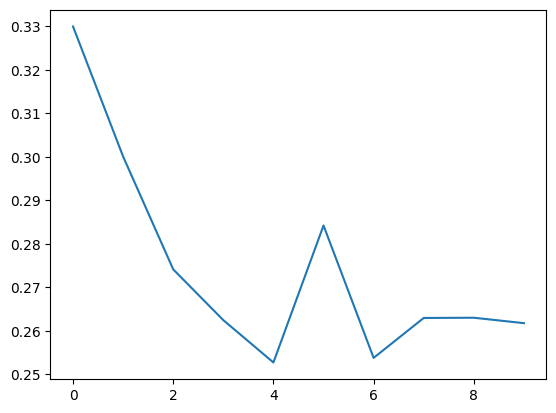

In [16]:
%%time
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MyNn(28 * 28, 10, hidden_sz=64).to(device)
# model = MyCnn(out_sz=10, ch=32).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
lossfn = nn.CrossEntropyLoss()
epochs = 10

loss_plot = []
for epoch in tqdm(range(epochs)):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.to(device)

        outs = model(images)
        loss = lossfn(outs, targets)
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.to(device)
            outs = model(images)
            loss = lossfn(outs, targets)
            losses.append(loss)
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

In [17]:
total = len(mnist_eval)
correct = 0
with torch.no_grad():
    for image, target in mnist_eval:
        pred = model(image.float().to(device))
        pred = F.softmax(pred, dim=1).argmax()
        if pred == target:
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

91.87% correct


In [18]:
from ipywidgets import interact

classes = {
    0:  "T-shirt/top",
    1: 	"Trouser",
    2: 	"Pullover",
    3: 	"Dress",
    4: 	"Coat",
    5: 	"Sandal",
    6: 	"Shirt",
    7: 	"Sneaker",
    8: 	"Bag",
    9: 	"Ankle boot",
}

@interact(index=(0, len(mnist_eval) - 1, 1))
def draw_preds(index=0):
    with torch.no_grad():
        image = mnist_eval[index][0]
        pred = model(image.float().to(device))
        pred = F.softmax(pred, dim=1)
        clsid = pred.argmax()
        plt.imshow(image.float().cpu().squeeze(), cmap='gray')
        print(classes[int(clsid)])

interactive(children=(IntSlider(value=0, description='index', max=9999), Output()), _dom_classes=('widget-inte…